# VEP

Variant Effect Prediction (VEP) using Protein Language Models.

In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
os.chdir(os.path.dirname(os.path.abspath('.')))

import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.ESM as ESM
import src.ESM_predict as ESMp
import src.gprofiler as gp
import src.vep_pipeline as vp
import src.proteingym as pg 
import src.ensembl_rest as er

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Import data

### Candidate proteins
A curated list of proteins that clinically relevant and incompletely penetrant across different ethnic populations.


### ProteinGym clinical mutations
Import set of clinical variants (substitutions and indels) to use for perturbing the wild-type protein sequences *in silico*.

In [3]:
proteins_df = pg.merge_resources()
proteins_df

Gathering resources: 100%|██████████| 2/2 [00:00<00:00,  2.23it/s]


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST
0,UPI0000167E20,UPI0000167E20,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI0000167E20,ENSG00000154027,ENSP00000346577,ENST00000354567
1,NP_003631.2,NP_003631,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_003631.2,ENSG00000070061,ENSP00000363779,ENST00000374647
2,NP_055147.1,NP_055147,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_055147.1,ENSG00000091482,ENSP00000368808,ENST00000379494
3,NP_001032.2,NP_001032,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_001032.2,ENSG00000090402,ENSP00000264382,ENST00000264382
4,NP_001243.1,NP_001243,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/NP_001243.1,ENSG00000125726,ENSP00000245903,ENST00000245903
...,...,...,...,...,...,...,...,...
4075,NP_004175.2,NP_004175,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_004175.2,ENSG00000140105,ENSP00000376620,ENST00000392882
4076,NP_006388.2,NP_006388,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_006388.2,ENSG00000104889,ENSP00000221486,ENST00000221486
4077,NP_000519.2,NP_000519,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000519.2,ENSG00000104774,ENSP00000395473,ENST00000456935
4078,UPI000013C755,UPI000013C755,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_indels,clinical_ProteinGym_indels/UPI000013C755,ENSG00000102195,ENSP00000218316,ENST00000218316


In [4]:
candidate_proteins = utils.get_candidate_proteins()
candidate_proteins = er.map_ids(df=candidate_proteins,
                                input_col="RefSeq Protein")
candidate_proteins

Loading ==> /grid/koo/home/schilder/.cache/ensembl_rest/xref_external/8d12557b44866d35ec3d553ddce6afea.json.gz


,Gene,Protein Common Name,RefSeq Protein,RefSeq Transcript,ENSP,RefSeq Protein Stable,ENSG,ENST
0,G6PD,Glucose-6-phosphate 1-dehydrogenase,NP_001346945.1,NM_001360016.2,ENSP00000377192,NP_001346945,ENSG00000160211,ENST00000393562
1,HFE,Homeostatic Iron Regulator,NP_000401.1,NM_000410.4,ENSP00000417404,NP_000401,ENSG00000010704,ENST00000357618
2,CFTR,Cystic Fibrosis Transmembrane Conductance Regu...,NP_000483.3,NM_000492.4,ENSP00000003084,NP_000483,ENSG00000001626,ENST00000003084
3,BRCA1,Breast Cancer Type 1 Susceptibility Protein,NP_009225.1,NM_007294.4,ENSP00000350283,NP_009225,ENSG00000012048,ENST00000357654
4,BRCA2,Breast Cancer Type 2 Susceptibility Protein,NP_000050.3,NM_000059.4,ENSP00000369497,NP_000050,ENSG00000139618,ENST00000380152
5,F5,Coagulation Factor V,NP_000121.2,NM_000130.5,ENSP00000356771,NP_000121,ENSG00000198734,ENST00000367797
6,HBB,Hemoglobin Subunit Beta,NP_000509.1,NM_000518.5,ENSP00000333994,NP_000509,ENSG00000244734,ENST00000335295
7,SERPINA1,Alpha-1 Antitrypsin,NP_000286.3,NM_000295.5,ENSP00000477615,NP_000286,ENSG00000277377,ENST00000620666
8,LDLR,Low-Density Lipoprotein Receptor,NP_000518.1,NM_000527.5,ENSP00000454071,NP_000518,ENSG00000130164,ENST00000558518
9,KCNQ1,Potassium Voltage-Gated Channel Subfamily Q Me...,NP_000209.2,NM_000218.3,ENSP00000488381,NP_000209,ENSG00000282076,ENST00000632153


Filter the ProteinGym mutations according to which ones are present in the candidate proteins.

### Haplotypes
Import haplotype sequences from Haplosaurus. 
These are the wild-type sequences for each protein that occurs within the 1000 Genomes Project.






In [5]:
# Download and import haplotypes (includes lots of other data/metadata)
haplotypes = hs.get_haplotypes(tx_ids=candidate_proteins["ENST"],
                               use_protein_ids=True, 
                               
                            #    max_tx_ids=10, # Can limit to a subset of transcripts for testing
                               cache_only=True # Set to true to speed up subsequent runs by only import from cache. Set to False if you're running this for the first time.
                               )

Getting haplotypes:   0%|          | 0/11 [00:00<?, ?it/s]

Filter the ProteinGym mutations according to which ones are present in the 1KG haplotypes data.

In [7]:
prot_df = vp.filter_prot_df(proteins_df,
                            haplotypes=haplotypes,
                            source_types="clinical_ProteinGym_substitutions",
                            protein_ids=candidate_proteins["ENSP"])
prot_df

Filtering by 11 protein ids
Filtering by 1 source types
Filtering by ENSP haplotypes
Returning 5 unique proteins


,protein,RefSeq peptide ID,source_file,source_type,experiment_id,ENSG,ENSP,ENST
364,NP_000483.3,NP_000483,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000483.3,ENSG00000001626,ENSP00000003084,ENST00000003084
606,NP_009225.1,NP_009225,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_009225.1,ENSG00000012048,ENSP00000350283,ENST00000357654
1256,NP_000401.1,NP_000401,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000401.1,ENSG00000010704,ENSP00000417404,ENST00000357618
2349,NP_000229.1,NP_000229,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000229.1,ENSG00000055118,ENSP00000262186,ENST00000262186
2770,NP_000509.1,NP_000509,/grid/koo/home/schilder/.cache/ProteinGym/clin...,clinical_ProteinGym_substitutions,clinical_ProteinGym_substitutions/NP_000509.1,ENSG00000244734,ENSP00000333994,ENST00000335295


## Run VEP pipeline

Run the VEP pipeline which iterates VEP over a series of models/proteins/haplotypes/variant source types/scoring strategies. 

The results are saved in a folder structure:  
{save_dir}/  
    {model}/  
    {protein_id}/  
        {haplotype}/  
        {source_type}/  
            {scoring_strategy1}.csv.gz  
            {scoring_strategy2}.csv.gz  
            {scoring_strategy3}.csv.gz  

List all models currently supported by the VEP pipeline.

In [8]:
vp.list_models()

['esm',
 'esm1_t12_85M_UR50S',
 'esm1_t34_670M_UR100',
 'esm1_t34_670M_UR50D',
 'esm1_t34_670M_UR50S',
 'esm1_t6_43M_UR50S',
 'esm1b_t33_650M_UR50S',
 'esm1v_t33_650M_UR90S',
 'esm1v_t33_650M_UR90S_1',
 'esm1v_t33_650M_UR90S_2',
 'esm1v_t33_650M_UR90S_3',
 'esm1v_t33_650M_UR90S_4',
 'esm1v_t33_650M_UR90S_5',
 'esm2_t12_35M_UR50D',
 'esm2_t30_150M_UR50D',
 'esm2_t33_650M_UR50D',
 'esm2_t36_3B_UR50D',
 'esm2_t48_15B_UR50D',
 'esm2_t6_8M_UR50D',
 'esm_if1_gvp4_t16_142M_UR50',
 'esm_msa1_t12_100M_UR50S',
 'esm_msa1b_t12_100M_UR50S',
 'esmfold_v0',
 'esmfold_v1']

Run VEP pipeline and store the results in `save_dir`.

In [9]:
save_dir = os.path.join(config.DATA_DIR,"1KG","vep")

In [ ]:
save_paths = vp.vep_pipeline(
    prot_df = prot_df,
    haplotypes = haplotypes,
    save_dir = save_dir,
    models = ["esm1v_t33_650M_UR90S_1"],
    scoring_strategies = {"esm1v_t33_650M_UR90S_1":[
        "wt-marginals", 
        "masked-marginals",
        # "pseudo-ppl" # Takes much longer to run
        ]},
    run_filter_prot_df=False,
    source_types = ["clinical_ProteinGym_substitutions"],
    verbose = False
    )
save_paths

## Explore VEP results

Automatically search for, import, and merge the VEP results. 
You can import only subsets of results by setting the save_dir to a lower level, e.g.: 
`os.path.join(save_dir,{model_name},{protein_id}})`

Setting `add_metadata=True` will automatically import additional variant-level metadata (collected from ProteinGym) which will be helpful for downstream plotting/analysis tasks.

In [11]:
vep_df = ESM.merge_vep(save_dir, 
                       add_metadata=True)
vep_df

No save_dir provided, using: /grid/koo/home/schilder/projects/data/1KG/vep
Found 257 wt-marginals files


Reading files: 100%|██████████| 257/257 [00:01<00:00, 215.44it/s]


Found 254 masked-marginals files


Reading files: 100%|██████████| 254/254 [00:01<00:00, 220.13it/s]


Found 204 pseudo-ppl files


Gathering resources: 100%|██████████| 2/2 [00:00<00:00, 30.35it/s]
/grid/it/data/elzar/easybuild/software/Python/3.9.5-GCCcore-10.3.0/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3301: DtypeWarning: Columns (0,47) have mixed types.Specify dtype option on import or set low_memory=False.
  if await self.run_code(code, result, async_=asy):


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,esm1v_t33_650M_UR90S_1,scoring_strategy,is_ref,model_location,...,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig
0,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,W10R,MGPWGWKLRRTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584725|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-2.108518,-0.002561,7,likely_path
1,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15P,MGPWGWKLRWTVALPLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA10584732|LDLR-LOVD,_British_Heart_Fo...",NaN,NaN,NaN,NaN,NaN,-6.361703,-0.008103,7,likely_path
2,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,L15R,MGPWGWKLRWTVALRLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,Pathogenic,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,NaN,NaN,NaN,NaN,NaN,NaN,-6.943518,-0.011925,7,likely_path
3,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,A18V,MGPWGWKLRWTVALLLAVAGTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA16602290,NaN,NaN,NaN,NaN,NaN,-0.349066,-0.000457,7,likely_benign
4,"ENSP00000252444:477A>T,800E>A",NP_000518.1,MGPWGWKLRWTVALLLAAAGTAVGDRCERNEFQCQDGKCISYKWVC...,G20R,MGPWGWKLRWTVALLLAAARTAVGDRCERNEFQCQDGKCISYKWVC...,Benign,NaN,wt-marginals,False,esm1v_t33_650M_UR90S_1,...,"ClinGen:CA023728|LDLR-LOVD,_British_Heart_Foun...",NaN,NaN,NaN,NaN,NaN,-0.693519,-0.002438,7,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47271,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,K9E,MVHLTPEEESAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Pathogenic,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA125050|OMIM:141900.0191|UniProtKB:P6...,NaN,NaN,NaN,-5.209094,-4.076734,-4.650674,-0.059732,9,path
47272,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,E8G,MVHLTPEGKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Benign,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA124863|HBVAR:230|OMIM:141900.0086|Un...,NaN,NaN,NaN,-5.896679,-5.485862,-6.678444,-0.111628,9,likely_benign
47273,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,E7V,MVHLTPVEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Pathogenic,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,ClinGen:CA125138|Genetic_Testing_Registry_(GTR...,.|.|.|.|.|.|MedGen:C1264000,HEMOGLOBIN_JAMAICA_PLAIN|HEMOGLOBIN_S_(ANTILLE...,446730:other|446731:other|446735:Pathogenic|44...,-4.408691,-2.442653,-3.244972,-0.056076,9,path
47274,ENSP00000333994:135V>A,NP_000509.1,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,P6A,MVHLTAEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...,Benign,-711.517793,pseudo-ppl,False,esm1v_t33_650M_UR90S_1,...,NaN,NaN,NaN,NaN,1.358990,1.112418,0.719250,0.019736,9,likely_benign


In [12]:
# haplotypes = hs.get_haplotypes(
#     cache_only=True 
#     ) 
# vep_df['protein_id'] = vep_df['haplotype'].str.split(':').str[0]

# vep_df = hs.add_haplotype_freqs(df= vep_df, 
#                                 haplotypes = haplotypes, 
#                                 haplotype_col = "haplotype")
# vep_df.head() 

In [13]:
seq_check_df, clinsig_counts, mutant_in_haplotype = ESM.report_vep(vep_df)
display(seq_check_df, clinsig_counts, mutant_in_haplotype)

,clinsig,mismatched_length,identical_sequences
0,benign,0,0
1,likely_benign,0,0
2,likely_path,0,0
3,path,0,0


,clinsig_count
likely_path,35655
likely_benign,5242
path,4966
benign,1413


,mutant_in_haplotype,clinsig,variant_count,variant_count_by_clinsig,variant_proportion,haplotype_count,haplotype_count_by_clinsig,haplotype_proportion
0,False,benign,16,24,0.666667,220,275,0.800000
1,False,likely_benign,86,93,0.924731,257,264,0.973485
2,False,likely_path,770,770,1.000000,238,238,1.000000
3,False,path,188,191,0.984293,70,74,0.945946
4,True,benign,8,24,0.333333,55,275,0.200000
5,True,likely_benign,7,93,0.075269,7,264,0.026515
6,True,path,3,191,0.015707,4,74,0.054054


Filtered 85.4% of rows with NAs in col 'esm1v_t33_650M_UR90S_1'


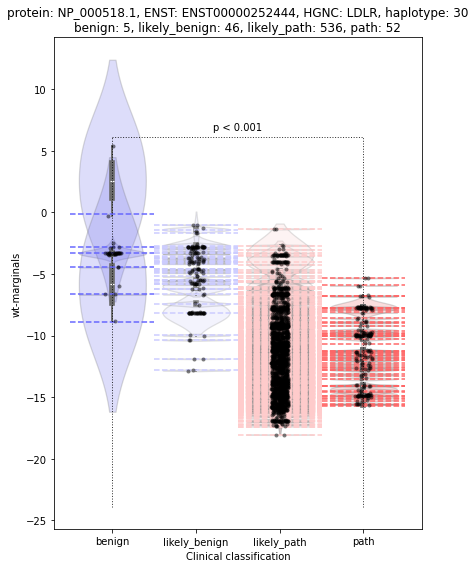

In [14]:
ESM.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    scoring_strategy="wt-marginals")

Filtered 85.0% of rows with NAs in col 'esm1v_t33_650M_UR90S_1'


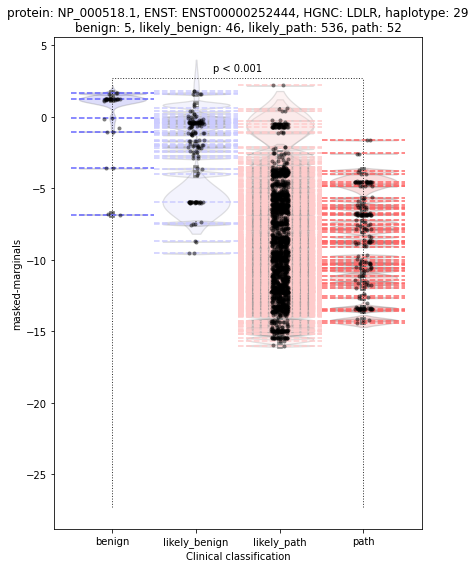

In [49]:
ESM.plot_vep_violin(vep_df, 
                    max_proteins=1,
                    scoring_strategy="masked-marginals")

Filtered 72.4% of rows with NAs in col 'esm1v_t33_650M_UR90S_1'


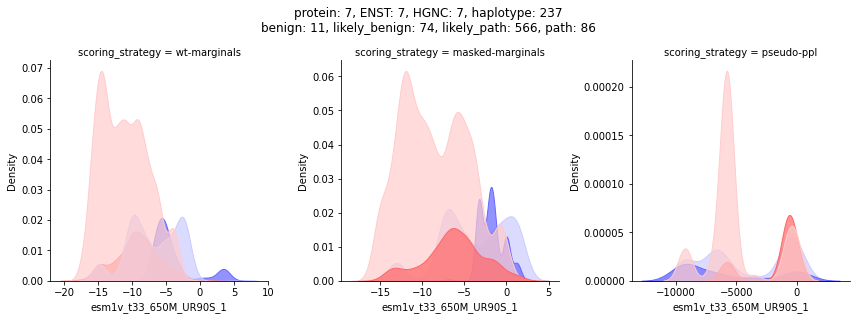

In [15]:
ESM.plot_vep_density(vep_df, multiple='layer')